 Реализация матричного метода для задачи линейной регрессии с L2-регуляризацией и сравнение с проксимальным и градиентным методом

--- Обучение моделей с lambda_reg = 0.1 ---

Матричный метод (Нормальное уравнение):
  Веса: [ 0.13423148  1.25746743 -0.43206721  1.68285598  0.03435238 -0.9062042 ]
  MSE на тестовой выборке: 0.6677

Градиентный спуск:
  Веса: [ 0.13423148  1.25746744 -0.4320672   1.68285597  0.03435239 -0.90620419]
  MSE на тестовой выборке: 0.6677
  Финальная стоимость: 0.6417

Проксимальный градиентный спуск:
  Веса: [ 0.13423148  1.25746744 -0.4320672   1.68285597  0.03435239 -0.90620419]
  MSE на тестовой выборке: 0.6677
  Финальная стоимость: 0.6417

Scikit-learn Ridge:
  Веса: [ 0.13414764  1.35476507 -0.4610022   1.85202837  0.02748251 -1.01320447]
  MSE на тестовой выборке: 0.5877


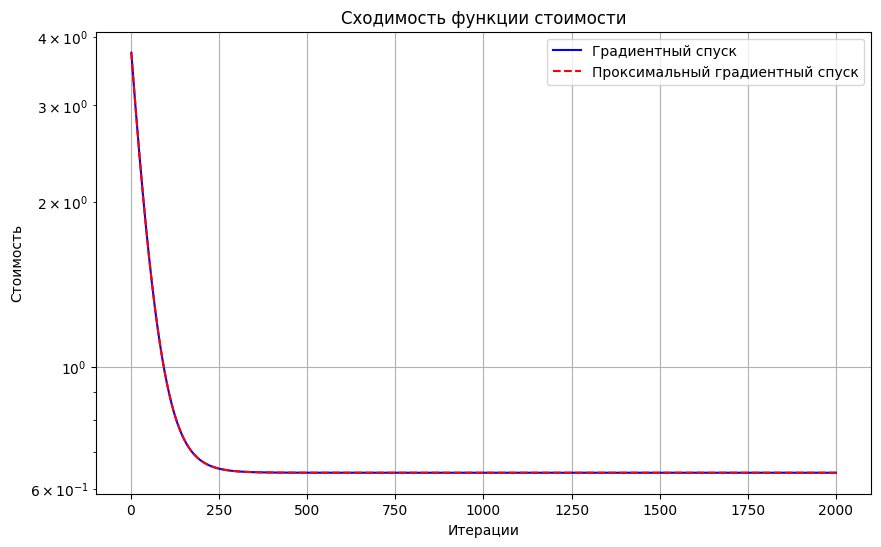

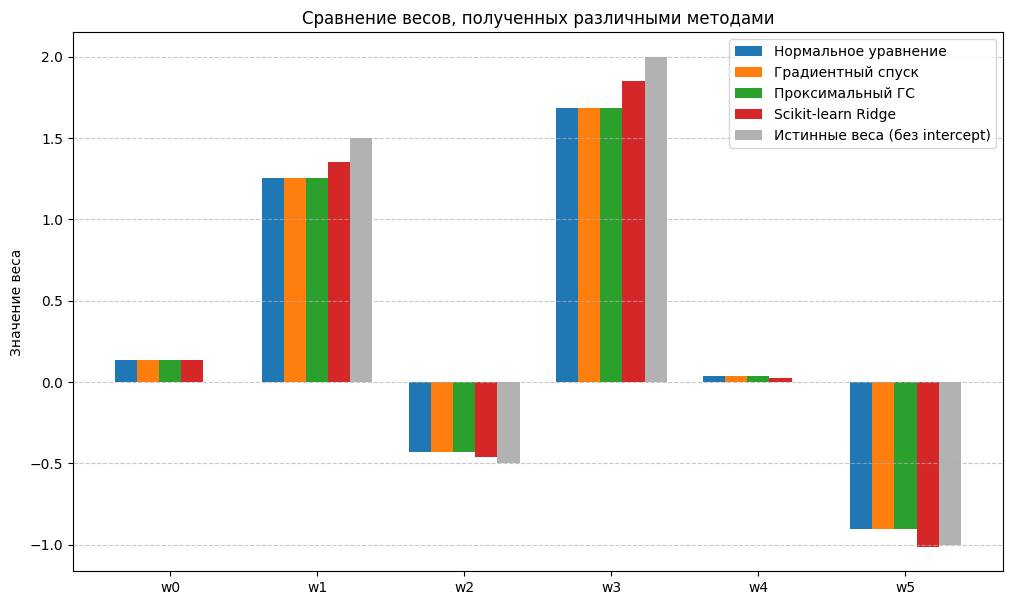

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge # Для сравнения

# --- 1. Генерация синтетических данных ---
np.random.seed(42)
n_samples = 200
n_features = 5
X = np.random.randn(n_samples, n_features)
# Истинные веса (с одним нулевым для демонстрации потенциального сжатия)
true_weights = np.array([1.5, -0.5, 2.0, 0.0, -1.0])
# Добавляем шум
y = X @ true_weights + np.random.randn(n_samples) * 0.8

# Разделение данных на обучающую и тестовую выборки
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Масштабирование признаков (важно для градиентных методов)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# Добавление столбца единиц для смещения (intercept)
X_train_b = np.c_[np.ones(X_train_scaled.shape[0]), X_train_scaled]
X_test_b = np.c_[np.ones(X_test_scaled.shape[0]), X_test_scaled]

n_samples_train = X_train_b.shape[0]
n_features_b = X_train_b.shape[1] # Количество признаков + 1 для смещения

# --- 2. Функция для вычисления стоимости (целевой функции) ---
def compute_cost(X, y, w, lambda_reg):
    """
    Вычисляет целевую функцию Ridge-регрессии.
    J(w) = 1/(2N) * ||Xw - y||^2 + lambda/2 * ||w||^2
    """
    n_samples = X.shape[0]
    predictions = X @ w
    mse_term = (1 / (2 * n_samples)) * np.sum((predictions - y)**2)
    # Исключаем смещение (w[0]) из регуляризации, как это часто делается
    reg_term = (lambda_reg / 2) * np.sum(w[1:]**2)
    return mse_term + reg_term

# --- 3. Реализация методов ---

def ridge_normal_equation(X, y, lambda_reg):
    """
    Реализация Ridge-регрессии с использованием матричного метода (нормального уравнения).
    w = (X^T X + N*lambda*I)^-1 X^T y
    """
    n_samples = X.shape[0]
    n_features = X.shape[1]

    # Создаем единичную матрицу для регуляризации.
    # Обратите внимание: w[0] (intercept) обычно не регуляризуется.
    # Поэтому первая строка/столбец в I обнуляется.
    I = np.identity(n_features)
    I[0, 0] = 0 # Не регуляризуем bias/intercept

    term1 = X.T @ X + n_samples * lambda_reg * I
    term2 = X.T @ y

    try:
        w = np.linalg.solve(term1, term2) # Более устойчиво, чем np.linalg.inv
    except np.linalg.LinAlgError:
        print("Ошибка: Матрица (X^T X + N*lambda*I) сингулярна. Попробуйте увеличить lambda_reg.")
        w = np.zeros(n_features) # Возвращаем нули в случае ошибки
    return w

def ridge_gradient_descent(X, y, lambda_reg, learning_rate, n_iterations):
    """
    Реализация Ridge-регрессии с использованием градиентного спуска.
    """
    n_samples = X.shape[0]
    n_features = X.shape[1]
    w = np.zeros(n_features) # Инициализация весов нулями
    cost_history = []

    for i in range(n_iterations):
        predictions = X @ w
        errors = predictions - y

        # Градиент для члена потерь
        grad_loss = (1 / n_samples) * X.T @ errors

        # Градиент для члена регуляризации (L2)
        grad_reg = lambda_reg * w
        grad_reg[0] = 0 # Не регуляризуем bias/intercept

        # Полный градиент
        gradient = grad_loss + grad_reg

        # Обновление весов
        w = w - learning_rate * gradient

        cost = compute_cost(X, y, w, lambda_reg)
        cost_history.append(cost)

    return w, cost_history

def ridge_proximal_gradient_descent(X, y, lambda_reg, learning_rate, n_iterations):
    """
    Реализация Ridge-регрессии с использованием проксимального градиентного спуска.
    """
    n_samples = X.shape[0]
    n_features = X.shape[1]
    w = np.zeros(n_features) # Инициализация весов нулями
    cost_history = []

    for i in range(n_iterations):
        # Шаг градиентного спуска для гладкой части f(w)
        grad_f = (1 / n_samples) * X.T @ (X @ w - y)
        v = w - learning_rate * grad_f

        # Шаг проксимального оператора для g(w) = (lambda/2)*||w||^2
        # w_new = v / (1 + alpha*lambda)
        # И снова, не применяем регуляризацию к intercept
        w_new = np.zeros_like(v)
        w_new[0] = v[0] # Intercept без регуляризации
        w_new[1:] = v[1:] / (1 + learning_rate * lambda_reg) # Остальные веса регуляризуются

        w = w_new

        cost = compute_cost(X, y, w, lambda_reg)
        cost_history.append(cost)

    return w, cost_history

# --- 4. Параметры обучения ---
lambda_reg = 0.1 # Параметр регуляризации L2
learning_rate = 0.01
n_iterations = 2000

# --- 5. Обучение моделей и оценка ---

print(f"--- Обучение моделей с lambda_reg = {lambda_reg} ---")

# Метод нормального уравнения
w_ne = ridge_normal_equation(X_train_b, y_train, lambda_reg)
y_pred_ne = X_test_b @ w_ne
mse_ne = mean_squared_error(y_test, y_pred_ne)
print(f"\nМатричный метод (Нормальное уравнение):")
print(f"  Веса: {w_ne}")
print(f"  MSE на тестовой выборке: {mse_ne:.4f}")

# Градиентный спуск
w_gd, costs_gd = ridge_gradient_descent(X_train_b, y_train, lambda_reg, learning_rate, n_iterations)
y_pred_gd = X_test_b @ w_gd
mse_gd = mean_squared_error(y_test, y_pred_gd)
print(f"\nГрадиентный спуск:")
print(f"  Веса: {w_gd}")
print(f"  MSE на тестовой выборке: {mse_gd:.4f}")
print(f"  Финальная стоимость: {costs_gd[-1]:.4f}")

# Проксимальный градиентный спуск
w_pgd, costs_pgd = ridge_proximal_gradient_descent(X_train_b, y_train, lambda_reg, learning_rate, n_iterations)
y_pred_pgd = X_test_b @ w_pgd
mse_pgd = mean_squared_error(y_test, y_pred_pgd)
print(f"\nПроксимальный градиентный спуск:")
print(f"  Веса: {w_pgd}")
print(f"  MSE на тестовой выборке: {mse_pgd:.4f}")
print(f"  Финальная стоимость: {costs_pgd[-1]:.4f}")

# --- 6. Сравнение с Scikit-learn (для проверки) ---
# Для sklearn, alpha - это параметр регуляризации.
# Если в нашей формуле cost = 1/(2N) * ||Xw - y||^2 + lambda/2 * ||w||^2,
# а в sklearn cost = ||Xw - y||^2 + alpha * ||w||^2,
# то alpha (sklearn) = N * lambda.
# Если в sklearn cost = 1/(2N) * ||Xw - y||^2 + alpha * ||w||^2,
# то alpha (sklearn) = lambda.
# Обычно sklearn использует формулу (1 / (2 * n_samples)) * sum((y - Xw)^2) + alpha * sum(w^2)
# То есть, alpha в sklearn соответствует нашей lambda_reg.
# Также, Ridge в sklearn по умолчанию не регуляризует intercept.
ridge_sklearn = Ridge(alpha=lambda_reg, fit_intercept=False, random_state=42) # fit_intercept=False, т.к. мы уже добавили столбец единиц
ridge_sklearn.fit(X_train_b, y_train)
y_pred_sklearn = ridge_sklearn.predict(X_test_b)
mse_sklearn = mean_squared_error(y_test, y_pred_sklearn)
print(f"\nScikit-learn Ridge:")
print(f"  Веса: {ridge_sklearn.coef_}")
print(f"  MSE на тестовой выборке: {mse_sklearn:.4f}")

# --- 7. Визуализация сходимости (для градиентных методов) ---
plt.figure(figsize=(10, 6))
plt.plot(range(1, n_iterations + 1), costs_gd, label='Градиентный спуск', color='blue')
plt.plot(range(1, n_iterations + 1), costs_pgd, label='Проксимальный градиентный спуск', color='red', linestyle='--')
plt.title('Сходимость функции стоимости')
plt.xlabel('Итерации')
plt.ylabel('Стоимость')
plt.legend()
plt.grid(True)
plt.yscale('log') # Часто удобно использовать логарифмическую шкалу для стоимости
plt.show()

# --- 8. Сравнение весов ---
labels = [f'w{i}' for i in range(n_features_b)]
x = np.arange(len(labels))
width = 0.15

fig, ax = plt.subplots(figsize=(12, 7))
ax.bar(x - 2*width, w_ne, width, label='Нормальное уравнение')
ax.bar(x - width, w_gd, width, label='Градиентный спуск')
ax.bar(x, w_pgd, width, label='Проксимальный ГС')
ax.bar(x + width, ridge_sklearn.coef_, width, label='Scikit-learn Ridge')
ax.bar(x + 2*width, np.concatenate(([0], true_weights)), width, label='Истинные веса (без intercept)', alpha=0.6, color='gray') # Добавим 0 для intercept

ax.set_ylabel('Значение веса')
ax.set_title('Сравнение весов, полученных различными методами')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
